In [1]:
import math, numpy as np, matplotlib.pyplot as plt, pandas as pd


In [2]:
#! Set working dir
import os
print(os.getcwd())
os.chdir("../")
print(os.getcwd())

f:\studium\Thesis_Repo\phase1_tgt_model
f:\studium\Thesis_Repo


In [ ]:
# Load Bus and Branch DataFrames

bus_df = pd.read_parquet('data_out/no_pertubations/case14_ieee/raw/bus_data.parquet')
branch_df = pd.read_parquet('data_out/no_pertubations/case14_ieee/raw/branch_data.parquet')

# Build Edge Index from Branch Data
structure = branch_df[branch_df['load_scenario_idx'] == 0].sort_values("idx")
edge_index = list(structure[['from_bus', 'to_bus']].itertuples(index=False, name=None))

# print dims
m = len(edge_index)
n=bus_df['bus'].nunique()
print(f"Topology Loaded: n={n} Nodes, m={m} Edges")

# X: Input Loads (Active Power 'Pd')
loads_pivot = bus_df.pivot(index='load_scenario_idx', columns='bus', values='Pd').fillna(0)
# Y: Target Flows (Active Power Flow 'pf')
flows_pivot = branch_df.pivot(index='load_scenario_idx', columns='idx', values='pf').fillna(0)

# Convert to Numpy Arrays
loads_matrix = loads_pivot.values.astype(np.float32)
flows_matrix = flows_pivot.values.astype(np.float32)
print(f"shapes: Loads: {loads_matrix.shape}, Flows: {flows_matrix.shape}")



Topology Loaded: n=14 Nodes, m=20 Edges
shapes: Loads: (8760, 14), Flows: (8760, 20)


C:\Users\monst\AppData\Local\Temp\ipykernel_17932\944267704.py:43: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  train_glob = global_load[:train_end_idx]
C:\Users\monst\AppData\Local\Temp\ipykernel_17932\944267704.py:44: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  rest_glob = global_load[train_end_idx:] # Val + Test zusammen
C:\Users\monst\AppData\Local\Temp\ipykernel_17932\944267704.py:60: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  axes[1,1].hist(bus_load[:train_end_idx], bins=50, alpha=0.6,

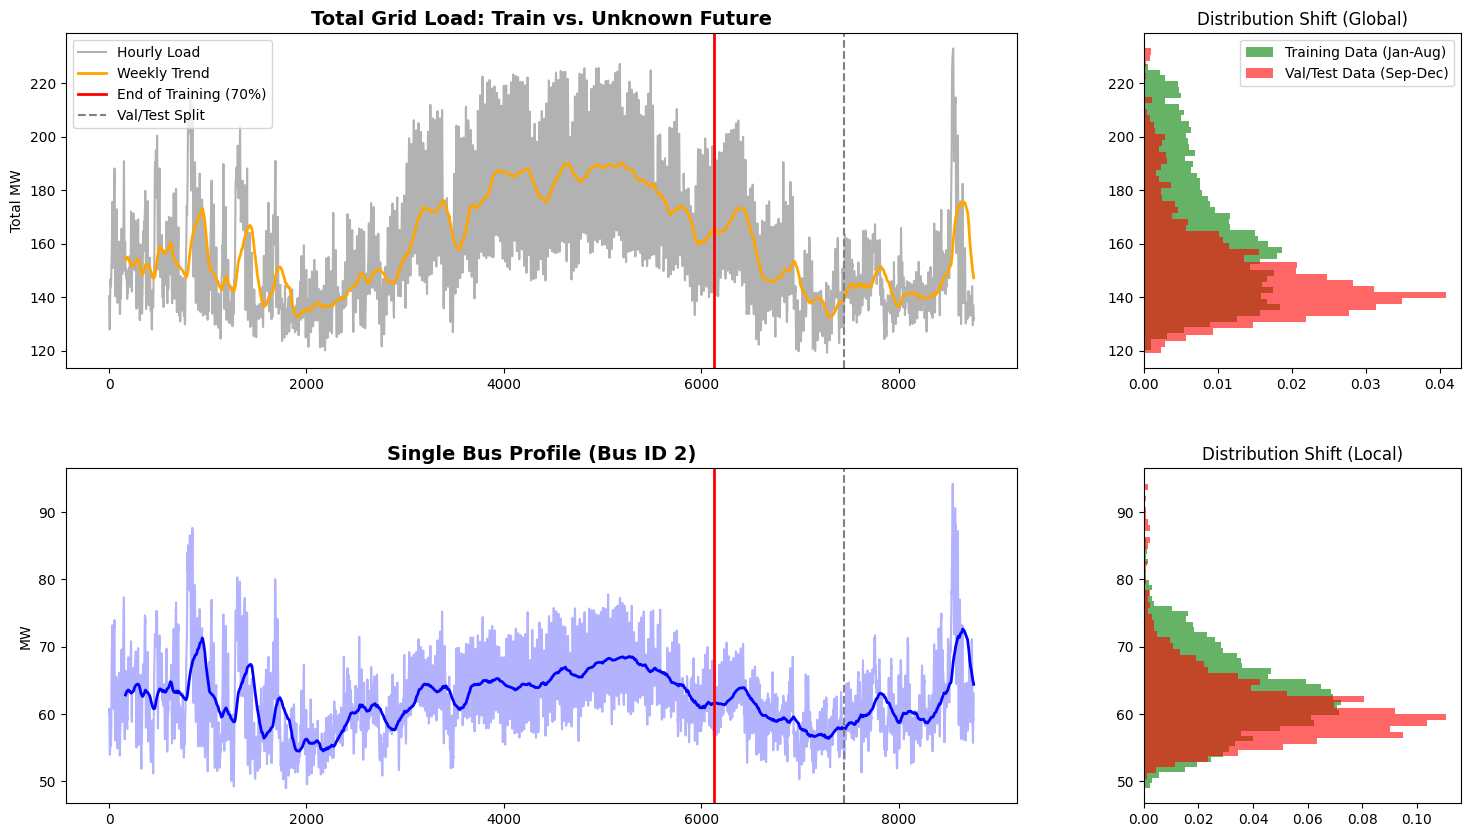

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# SETUP
# ---------------------------------------------------------
# data shape: (8760, 14)
values = loads_pivot 

# 1. SPLIT DEFINITION (Korrigiert auf 0.7)
train_end_idx = int(8760 * 0.70)  # Hier endet das Wissen des Modells
val_end_idx = int(8760 * 0.85)    # (Optional) Grenze Val/Test

# 2. DATEN SELEKTION
# A. Global Load (Der Hauptbeweis)
global_load = np.sum(values, axis=1)

# B. Heavy Hitter (Der "Bus Level" Beweis)
# Wir nehmen nur den Bus mit der höchsten Last, um zu zeigen, dass es auch lokal passiert
heavy_bus_idx = np.argmax(np.mean(values, axis=0))
bus_load = values[heavy_bus_idx]

# ---------------------------------------------------------
# PLOTTING (Clean & Focused)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.3)

# --- ROW 1: TOTAL GRID LOAD ---
# Time Series
axes[0,0].plot(global_load, color='black', alpha=0.3, label='Hourly Load')
axes[0,0].plot(pd.Series(global_load).rolling(168).mean(), color='orange', linewidth=2, label='Weekly Trend')
# Rote Linie bei 70% (End of Training)
axes[0,0].axvline(train_end_idx, color='red', linestyle='-', linewidth=2, label='End of Training (70%)')
# Graue Linie bei 85% (Val/Test Split)
axes[0,0].axvline(val_end_idx, color='gray', linestyle='--', label='Val/Test Split')
axes[0,0].set_title("Total Grid Load: Train vs. Unknown Future", fontsize=14, fontweight='bold')
axes[0,0].legend(loc='upper left')
axes[0,0].set_ylabel("Total MW")

# Histogram: Train (0-70%) vs. The Rest (70-100%)
train_glob = global_load[:train_end_idx]
rest_glob = global_load[train_end_idx:] # Val + Test zusammen
axes[0,1].hist(train_glob, bins=50, alpha=0.6, color='green', density=True, label='Training Data (Jan-Aug)', orientation='horizontal')
axes[0,1].hist(rest_glob, bins=50, alpha=0.6, color='red', density=True, label='Val/Test Data (Sep-Dec)', orientation='horizontal')
axes[0,1].set_title("Distribution Shift (Global)", fontsize=12)
axes[0,1].legend()

# --- ROW 2: SINGLE BUS LOAD ---
# Time Series
axes[1,0].plot(bus_load, color='blue', alpha=0.3)
axes[1,0].plot(pd.Series(bus_load).rolling(168).mean(), color='blue', linewidth=2)
axes[1,0].axvline(train_end_idx, color='red', linestyle='-', linewidth=2)
axes[1,0].axvline(val_end_idx, color='gray', linestyle='--')
axes[1,0].set_title(f"Single Bus Profile (Bus ID {heavy_bus_idx})", fontsize=14, fontweight='bold')
axes[1,0].set_ylabel("MW")

# Histogram
axes[1,1].hist(bus_load[:train_end_idx], bins=50, alpha=0.6, color='green', density=True, orientation='horizontal')
axes[1,1].hist(bus_load[train_end_idx:], bins=50, alpha=0.6, color='red', density=True, orientation='horizontal')
axes[1,1].set_title("Distribution Shift (Local)", fontsize=12)

plt.show()

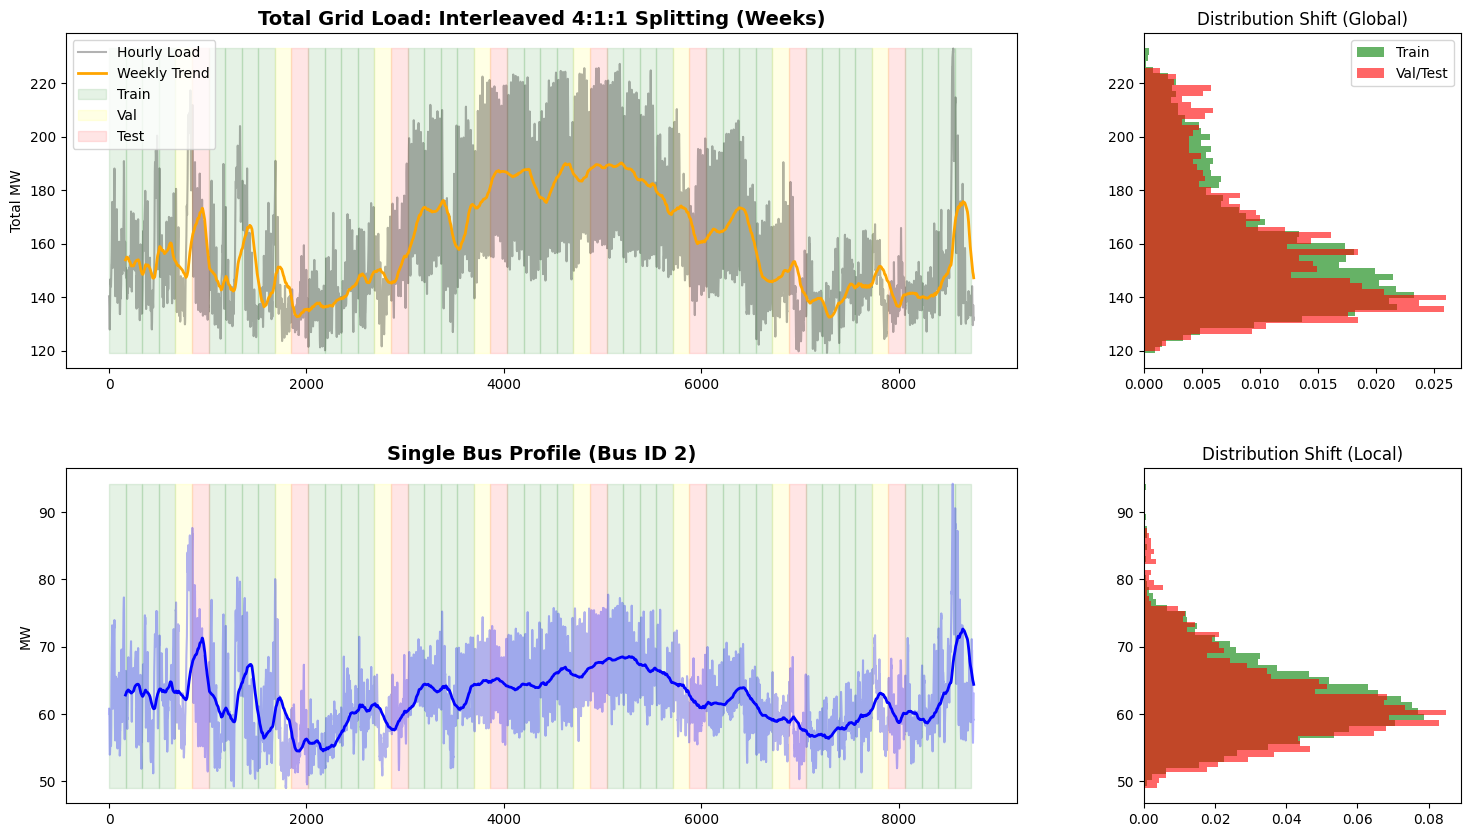

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from phase1_tgt_model.src.splitting import get_interleaved_splits

# Mock CONFIG for interleaved splitting (adjust as needed)
CONFIG = {
    "BLOCK_SIZE_HOURS": 168,  # 1 week
    "CYCLE_SCHEME": 6,
    "INPUT_WINDOW": 168  # Assume same as block size
}

# ---------------------------------------------------------
# SETUP
# ---------------------------------------------------------
# data shape: (8760, 14)
values = loads_pivot 

T = len(values)
train_idx, val_idx, test_idx = get_interleaved_splits(T, CONFIG)

# 2. DATEN SELEKTION
# A. Global Load (Der Hauptbeweis)
global_load = np.sum(values, axis=1)

# B. Heavy Hitter (Der "Bus Level" Beweis)
heavy_bus_idx = np.argmax(np.mean(values, axis=0))
bus_load = values[heavy_bus_idx]

# ---------------------------------------------------------
# PLOTTING (Clean & Focused)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.3)

# --- ROW 1: TOTAL GRID LOAD ---
# Time Series
axes[0,0].plot(global_load, color='black', alpha=0.3, label='Hourly Load')
axes[0,0].plot(pd.Series(global_load).rolling(168).mean(), color='orange', linewidth=2, label='Weekly Trend')

# Shade interleaved regions
n_blocks = T // CONFIG["BLOCK_SIZE_HOURS"]
for i in range(n_blocks):
    start_t = i * CONFIG["BLOCK_SIZE_HOURS"]
    end_t = min((i + 1) * CONFIG["BLOCK_SIZE_HOURS"], T)
    cycle_pos = i % CONFIG["CYCLE_SCHEME"]
    if cycle_pos in [0, 1, 2, 3]:
        axes[0,0].fill_betweenx([global_load.min(), global_load.max()], start_t, end_t, color='green', alpha=0.1, label='Train' if i == 0 else "")
    elif cycle_pos == 4:
        axes[0,0].fill_betweenx([global_load.min(), global_load.max()], start_t, end_t, color='yellow', alpha=0.1, label='Val' if i == 4 else "")
    elif cycle_pos == 5:
        axes[0,0].fill_betweenx([global_load.min(), global_load.max()], start_t, end_t, color='red', alpha=0.1, label='Test' if i == 5 else "")

axes[0,0].set_title("Total Grid Load: Interleaved 4:1:1 Splitting (Weeks)", fontsize=14, fontweight='bold')
axes[0,0].legend(loc='upper left')
axes[0,0].set_ylabel("Total MW")

# Histogram: Train vs. Val/Test
train_glob = global_load[train_idx]
val_test_glob = global_load[np.concatenate((val_idx, test_idx))]
axes[0,1].hist(train_glob, bins=50, alpha=0.6, color='green', density=True, label='Train', orientation='horizontal')
axes[0,1].hist(val_test_glob, bins=50, alpha=0.6, color='red', density=True, label='Val/Test', orientation='horizontal')
axes[0,1].set_title("Distribution Shift (Global)", fontsize=12)
axes[0,1].legend()

# --- ROW 2: SINGLE BUS LOAD ---
# Time Series
axes[1,0].plot(bus_load, color='blue', alpha=0.3)
axes[1,0].plot(pd.Series(bus_load).rolling(168).mean(), color='blue', linewidth=2)

# Shade interleaved regions
for i in range(n_blocks):
    start_t = i * CONFIG["BLOCK_SIZE_HOURS"]
    end_t = min((i + 1) * CONFIG["BLOCK_SIZE_HOURS"], T)
    cycle_pos = i % CONFIG["CYCLE_SCHEME"]
    if cycle_pos in [0, 1, 2, 3]:
        axes[1,0].fill_betweenx([bus_load.min(), bus_load.max()], start_t, end_t, color='green', alpha=0.1)
    elif cycle_pos == 4:
        axes[1,0].fill_betweenx([bus_load.min(), bus_load.max()], start_t, end_t, color='yellow', alpha=0.1)
    elif cycle_pos == 5:
        axes[1,0].fill_betweenx([bus_load.min(), bus_load.max()], start_t, end_t, color='red', alpha=0.1)

axes[1,0].set_title(f"Single Bus Profile (Bus ID {heavy_bus_idx})", fontsize=14, fontweight='bold')
axes[1,0].set_ylabel("MW")

# Histogram
train_bus = bus_load[train_idx]
val_test_bus = bus_load[np.concatenate((val_idx, test_idx))]
axes[1,1].hist(train_bus, bins=50, alpha=0.6, color='green', density=True, orientation='horizontal')
axes[1,1].hist(val_test_bus, bins=50, alpha=0.6, color='red', density=True, orientation='horizontal')
axes[1,1].set_title("Distribution Shift (Local)", fontsize=12)

plt.show()

In [8]:
loads_pivot[1].shape

(8760,)

load_scenario_idx
0.0       140.354191
1.0       139.738564
2.0       137.440901
3.0       135.388614
4.0       133.675717
             ...    
8755.0    135.793209
8756.0    133.362008
8757.0    131.796593
8758.0    131.348566
8759.0    132.334138
Length: 8760, dtype: float64
--- Original series ---
ADF Statistic: -5.0772, p-value: 0.0000
Stationary 


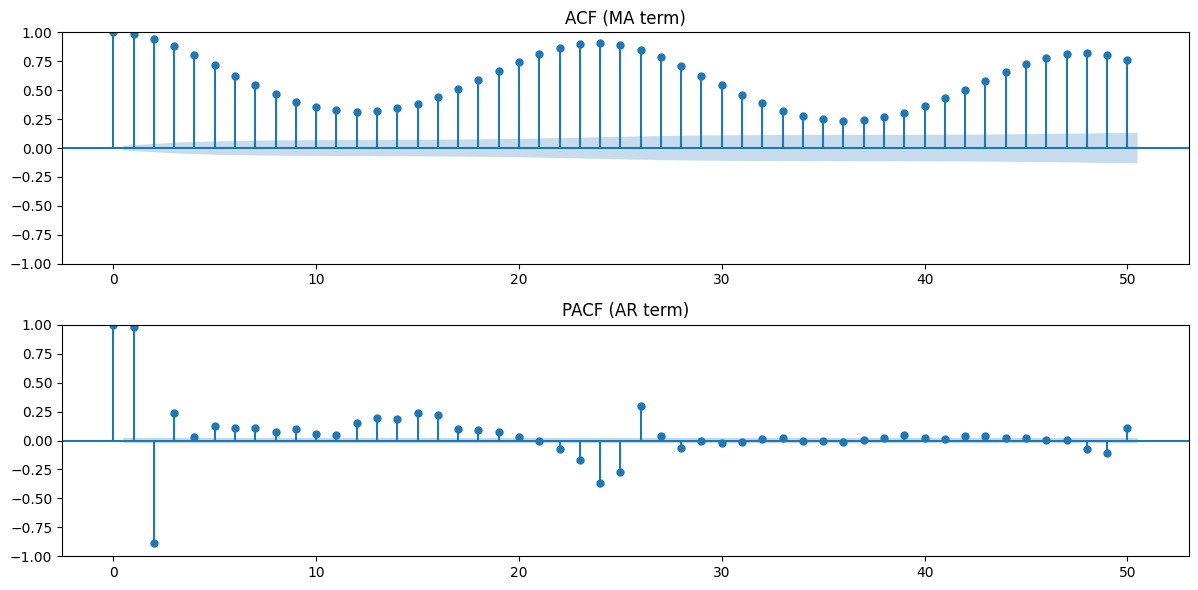

In [ ]:
# SARIMA param finding

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_stationarity(ts, lags=50):
    # drop NaNs
    ts = ts[~np.isnan(ts)] if isinstance(ts, np.ndarray) else ts.dropna()
    
    # ADF test
    try:
        stat, p = adfuller(ts)[:2]
        print(f'ADF Statistic: {stat:.4f}, p-value: {p:.4f}')
        print("Stationary " if p < 0.05 else "Non-stationary ")
    except Exception as e:
        print(f"ADF failed: {e}")

    # ACF/PACF plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    plot_acf(ts, ax=ax1, lags=lags, title="ACF (MA term)")
    plot_pacf(ts, ax=ax2, lags=lags, title="PACF (AR term)")
    plt.tight_layout()
    plt.show()

sample_series = np.sum(loads_pivot, axis=1)

print("--- Original series ---")
analyze_stationarity(sample_series)



f:\studium\Thesis_Repo\.venv\Lib\site-packages\statsmodels\tsa\statespace\tools.py:284: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  differenced = sdiffed[seasonal_periods:]


--- After Seasonal Differencing ---
ADF Statistic: -14.1634, p-value: 0.0000
Stationary 


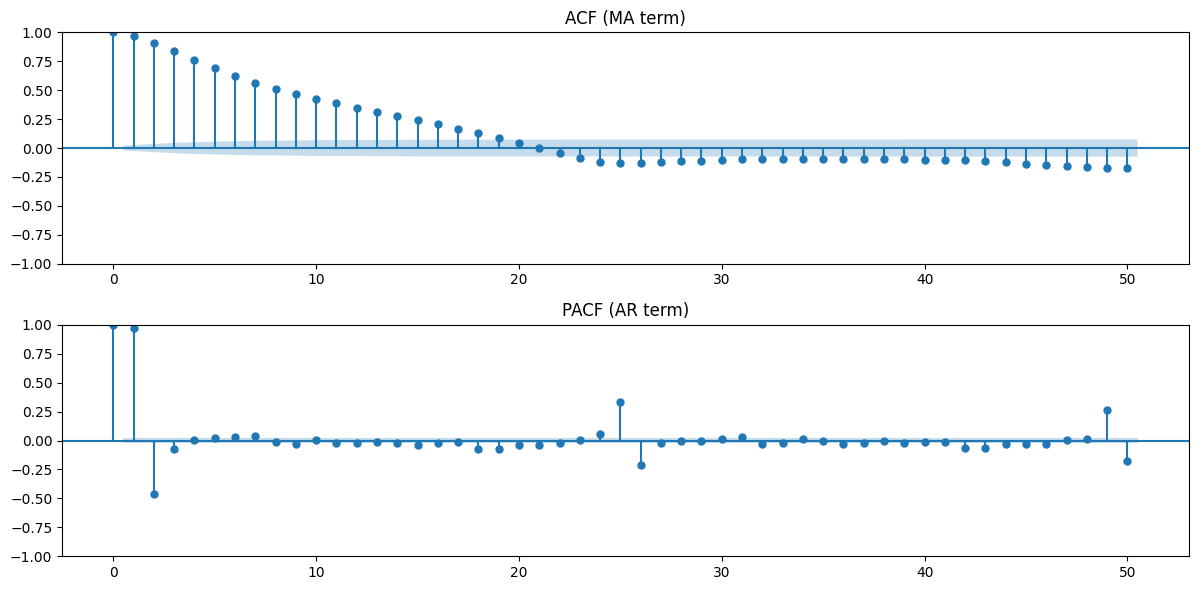

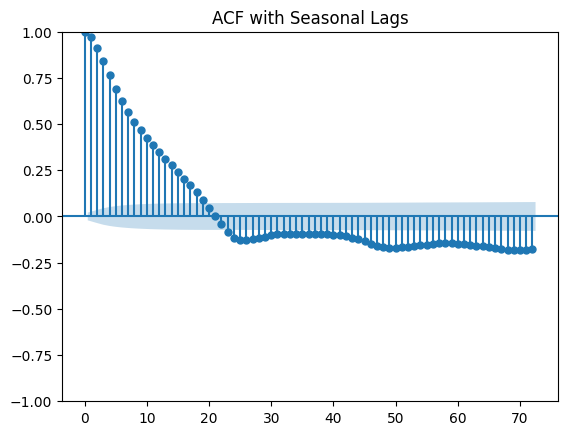

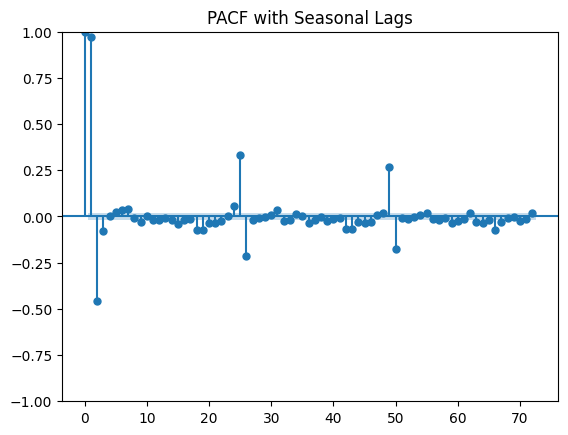

In [49]:
# After analyze_stationarity, add seasonal checks
from statsmodels.tsa.statespace.tools import diff

# Seasonal differencing (e.g., lag 24 for daily)
seasonal_diff = diff(sample_series, k_diff=0, k_seasonal_diff=1, seasonal_periods=24)

print("--- After Seasonal Differencing ---")
analyze_stationarity(seasonal_diff)

# For seasonal AR/MA, plot ACF/PACF with seasonal lags
plot_acf(seasonal_diff, lags=72, title="ACF with Seasonal Lags")  # Include multiples of 24
plot_pacf(seasonal_diff, lags=72, title="PACF with Seasonal Lags")
plt.show()